In [92]:
import pandas as pd
from pathlib import Path
import seaborn as sns

In [93]:
root = Path("..")

In [94]:
DATASET_DIR = root / "data"
DATASET_DIR.exists() # has to be True

True

In [95]:
DATASET_PATH = DATASET_DIR / "raw" / "dataset.csv"
DATASET_PATH.exists() # must be True

True

In [96]:
df = pd.read_csv(DATASET_PATH)
df.head()

,Role,Message Number,Sentence Number,Sentence,Tag
0,Proponent,0,0,Hello!,Intro
1,Proponent,0,1,What is the type of knowledge that is injected...,Ask_Info
2,Proponent,2,0,Interesting!,Give_Opinion
3,Proponent,2,1,What is the problem used to perform the experi...,Ask_Info
4,Proponent,4,0,"Yes, thank you",Reply_Info


In [97]:
df_true = df.copy(deep=True)

#### Convert all column names and tags to lowercase for convenience

In [98]:
df.columns = [p.lower() for p in df.columns.to_list()]
df["tag"] = df["tag"].str.lower()

In [99]:
df.columns

Index(['role', 'message number', 'sentence number', 'sentence', 'tag'], dtype='str')

In [100]:
df.head()

,role,message number,sentence number,sentence,tag
0,Proponent,0,0,Hello!,intro
1,Proponent,0,1,What is the type of knowledge that is injected...,ask_info
2,Proponent,2,0,Interesting!,give_opinion
3,Proponent,2,1,What is the problem used to perform the experi...,ask_info
4,Proponent,4,0,"Yes, thank you",reply_info


#### Engineer "dialogue_id" from "role" and "message number"

In [101]:
df = df.reset_index(drop=True)

In [102]:
is_p0 = (df["role"] == "Proponent") & (df["message number"] == 0)
prev_is_p0 = is_p0.shift(fill_value=False)
new_dialogue = is_p0 & ~prev_is_p0

In [103]:
df["dialogue number"] = new_dialogue.cumsum() - 1 # starting from 0

In [104]:
df["dialogue number"].nunique()

41

#### "Intro" and "Outro" tags are not informative

In [110]:
intro_outro_count = df_true[df_true["Tag"].isin(["Intro", "Outro"])].shape[0]
total_messages_count = df_true.shape[0]
intro_outro_count, total_messages_count, total_messages_count - intro_outro_count

(131, 881, 750)

In [109]:
df = df[~df["tag"].isin(["intro", "outro"])]

In [111]:
df["tag"].unique()

<StringArray>
['ask_info', 'give_opinion', 'reply_info', 'ask_suggestion', 'ask_rebuttal']
Length: 5, dtype: str

In [112]:
df.shape

(750, 6)

#### View distribution for each intent tag

In [113]:
tag_freq = pd.DataFrame(df["tag"].value_counts()).reset_index(names=["tag", "count"])
tag_freq.rename(columns={"tag": "Intent", "count": "Frequency"}, inplace=True)

In [114]:
tag_freq

,Intent,Frequency
0,reply_info,322
1,ask_info,221
2,give_opinion,123
3,ask_rebuttal,49
4,ask_suggestion,35


In [115]:
tag_freq.loc[tag_freq["Intent"].isin(["ask_info", "reply_info", "ask_suggestion"])==False, "Label Group"] = "ARG"
tag_freq.loc[tag_freq["Intent"].isin(["ask_info", "reply_info", "ask_suggestion"])==True, "Label Group"] = "EXP"

<Axes: xlabel='Intent', ylabel='Frequency'>

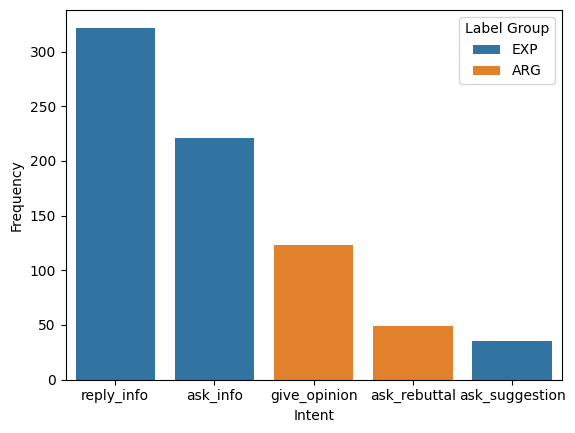

In [116]:
sns.barplot(data=tag_freq, x="Intent", y="Frequency", hue="Label Group")

- Note: 
There is data imbalance between exploratory and argumentative texts. 

In [117]:
PROCESSED_DIR = root / "data" / "processed"
PROCESSED_DIR.mkdir(exist_ok=True, parents=True)

In [118]:
df.info()

<class 'pandas.DataFrame'>
Index: 750 entries, 1 to 880
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   role             750 non-null    str  
 1   message number   750 non-null    int64
 2   sentence number  750 non-null    int64
 3   sentence         750 non-null    str  
 4   tag              750 non-null    str  
 5   dialogue number  750 non-null    int64
dtypes: int64(3), str(3)
memory usage: 41.0 KB


In [119]:
df.columns = ["_".join(p.split(" ")) for p in df.columns]
df.columns

Index(['role', 'message_number', 'sentence_number', 'sentence', 'tag',
       'dialogue_number'],
      dtype='str')

In [120]:
df.to_csv(PROCESSED_DIR / "processed_df_0.csv", index=False)